**Aufgabe 2.a**

In dieser Teilaufgabe schreiben wir das System der GDLen vom Hodgkin-Huxley-Model und implementieren das Euler-Verfahren, um dieses System für Zeitraum $t_0 = 50$ ms und konstanten Strom $I = I_0 = 10$ nA. Für die Teilaufgabe verwendeten Module finden Sie in “aufgabe2.ode_solver_euler.py”, das “aufgabe2.equations.py” aufruft, um wie Gleichungen geschrieben sind. Die Funktion 'equations.equtions_vector(x_0, I, C)' rechnet die Werte der DGLen für $V, n, m, h$ für einen Zeitpunkt $t$. Diese wird bei 'aufgabe2.ode_solver_euler.py' für Eulers
$$\vec{s}(t + \Delta t) = \vec{s}(t) + \Delta t \vec{f}(t)$$
aufgerufen. Wobei
$$\vec{s} := (V, n, m, h), \ \text{Zustandsvektor}$$
und
$$\vec{f}(t) := (f_V, f_n, f_m, f_h), \ \text{Vektor der DGLen}$$


Es ist zu merken, dass $\alpha_n$ und $\alpha_m$ bei den Werten $V_0 = -55$ mV bzw. $V_0 = -40$ mV die Unbestimmte Form $\frac{0}{0}$ haben. Dementsprechend ist es sinnvoll neben diesen Punkten für numerische Stabilität die Taylor-Entwicklung anzuwenden. Es gilt:
$$\alpha = -c\frac{V_0 + V}{e^{-(V_0 + V)/10} - 1} = 10c \frac{x}{e^x - 1} = 10c (1- \frac{x}{2} + \frac{x^2}{12} + O(x^3))$$
mit
$$x = -\frac{V_0 + V}{10}$$

Um die Gleichgewichtswerte für die Gating-Variablen $n_\infty, m_\infty, h_\infty$ setzen wir den Wert $V = -65$ mV in die Gleichung (16) aus der Aufgabe 1.a ein. Dann gilt es:
$$n_\infty = \alpha(V_{pot}) = \frac{\alpha(V_{pot}) }{\alpha(V_{pot}) + \beta(V_{pot})} \approx 0.3177$$
$$m_\infty \approx  0.0529 $$
$$h_\infty \approx 0.5961$$

In der unteren Zelle befindet sich eine Visualisation des Verlaufs von Membranspannung über Zeitraum vom 50ms, für die wir 'matplotlib'-Bibliothek verwenden.

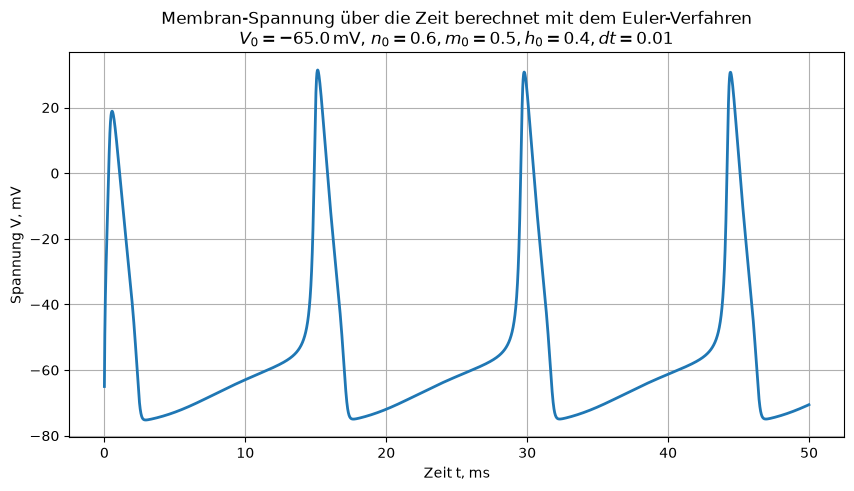

In [1]:
from aufgabe2 import visualizer
import numpy as np


V_0 = -65
n_0 = 0.6
m_0 = 0.5
h_0 = 0.4
x_0 = np.array([V_0,n_0, m_0, h_0])
t_a = 0
t_b = 50
dt = 0.01
I_0 = 10

visualizer.visualize_euler_method(x_0, I_0, t_a, t_b, dt)


**Aufgabe 2.b**

Nun implementieren wir das Runge-Kutta-Verfahren des 4. Grads. Der Code befindet sich in 'aufgabe2.ode_solver_runge_kutta'.

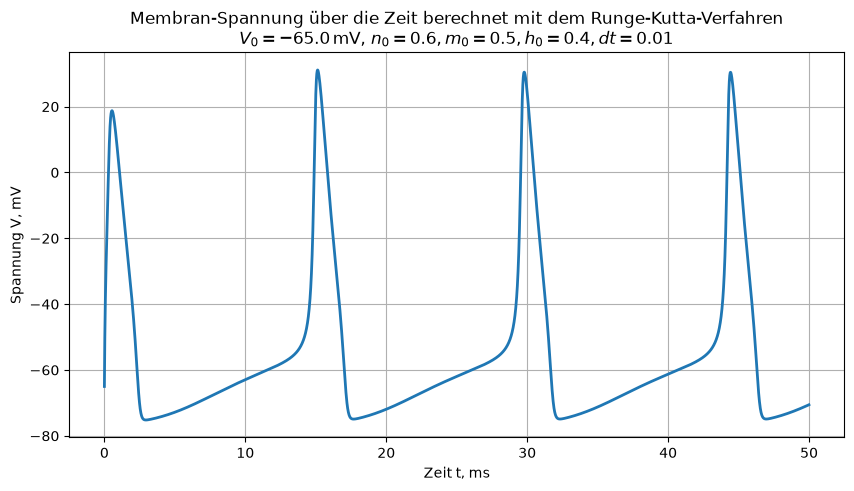

In [2]:
from aufgabe2 import visualizer

visualizer.visualize_runge_kutta_method(x_0, I_0, t_a, t_b, dt)

Eben lösen wir das Gleihungssystem mit 'scipy.odeint'. Der Code befindet sich in 'aufgabe2.ode_solver_odeint'.

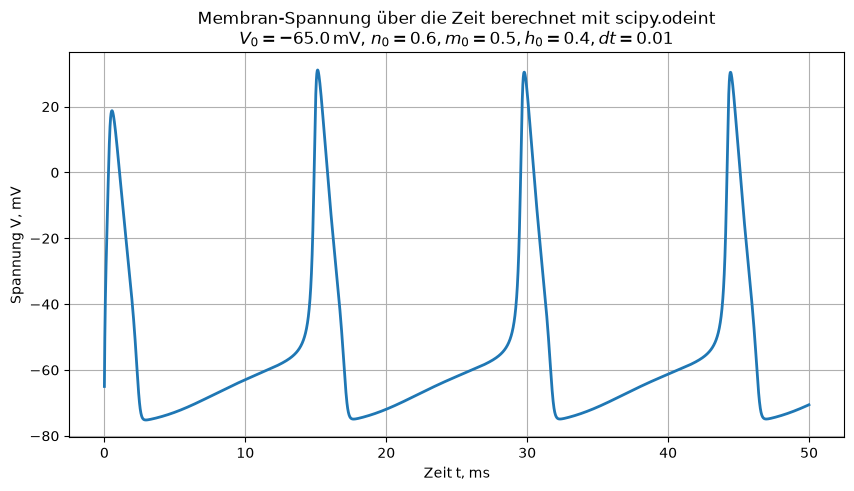

In [4]:
from aufgabe2 import visualizer

tpoints = np.arange(t_a, t_b, dt)


visualizer.visualize_odeint(tpoints, I_0 , dt)

In den folgenden Zellen sind die Ergebnisse von der Untersuchung aller drei Verfahren auf Laufzeit für unterschiedliche Zeitschritten von 0.01 ms bis zu 1 ms sowie für Stabilität. Eine einzelne Laufzeit wird mit pythons 'time.perf_counter()' gemessen und das Ergebnislaufzeit wird als Mittelwert gegeben, da die Laufzeit jedes einzelnen Aufrufs schwankt. Der Code für den Test befindet sich im Modul 'aufgabe2.performance_tester'. Aus den Ergebnissen folgt, dass wie erwartet:
1. Das Euler-Verfahren mindestens dreifach schneller als das Runge-Kutte-Verfahren ist.
2. Das Runge-Kutte-Verfahren stabiler ist. d.h. für größeres Interval der Zeitschritte Lösung liefert.
3. scipy.odeint signifikant sowohl schneller als auch stabiler als Euler-und-Runge-Kutta-Verfahren ist und seine Laufzeit kaum von dem Zeitschritt abhängt.


Unter können Sie Visualisation der Ergebnisse sehen.

C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\equations.py:146: RuntimeWarning: overflow encountered in scalar multiply
  - G_NA * (m ** 3) * h * (voltage - V_NA)
C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\equations.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return 0.1 * x / (exp(x) - 1)
C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\equations.py:26: RuntimeWarning: invalid value encountered in scalar divide
  return x / (exp(x) - 1)
C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\equations.py:145: RuntimeWarning: overflow encountered in scalar power
  - G_K * (n ** 4) * (voltage - V_K)
C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\equations.py:146: RuntimeWarning: overflow encountered in scalar power
  - G_NA * (m ** 3) * h * (voltage - V_NA)
C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\equations.py:144: RuntimeWarning: invalid value encountered in scalar subtract
  dvdt = (I
C:\Use

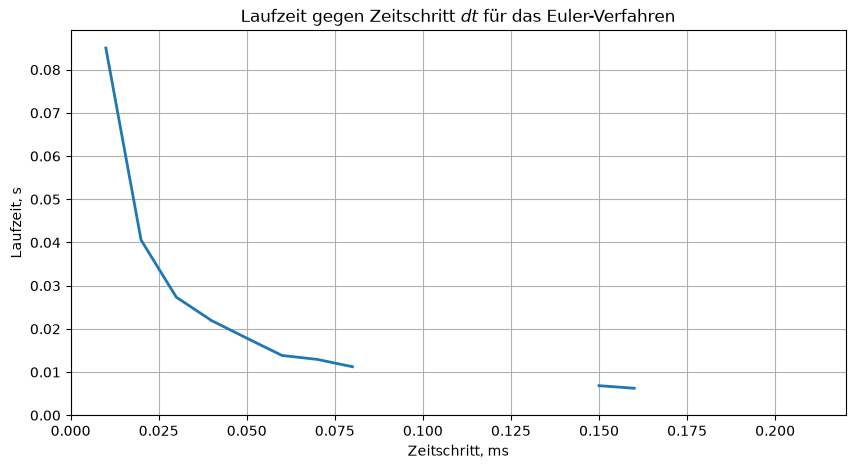

In [5]:
from aufgabe2 import visualizer

time_steps = np.arange(0.01, 1, 0.01)

euler_array = visualizer.visualize_euler_performance(x_0, t_a, t_b, time_steps, I_0)

C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\equations.py:145: RuntimeWarning: overflow encountered in scalar multiply
  - G_K * (n ** 4) * (voltage - V_K)


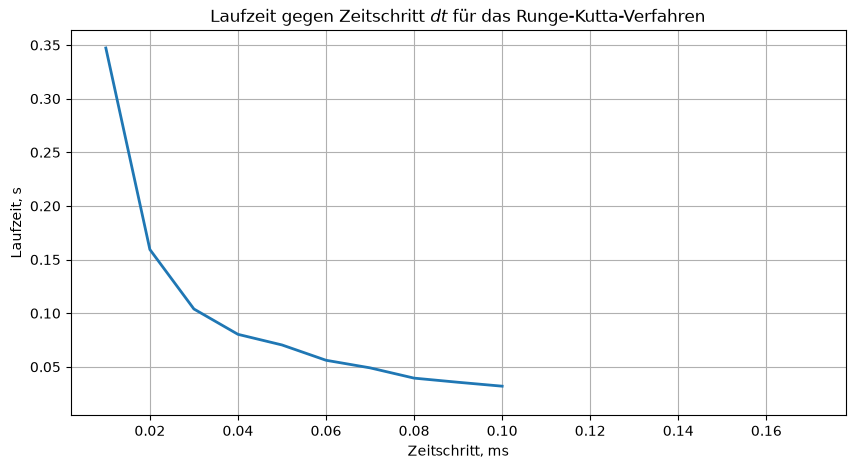

In [6]:
from aufgabe2 import visualizer

time_steps = np.arange(0.01, 1, 0.01)

runge_kutta_array = visualizer.visualize_runge_kutta_performance(x_0, t_a, t_b, time_steps, I_0)

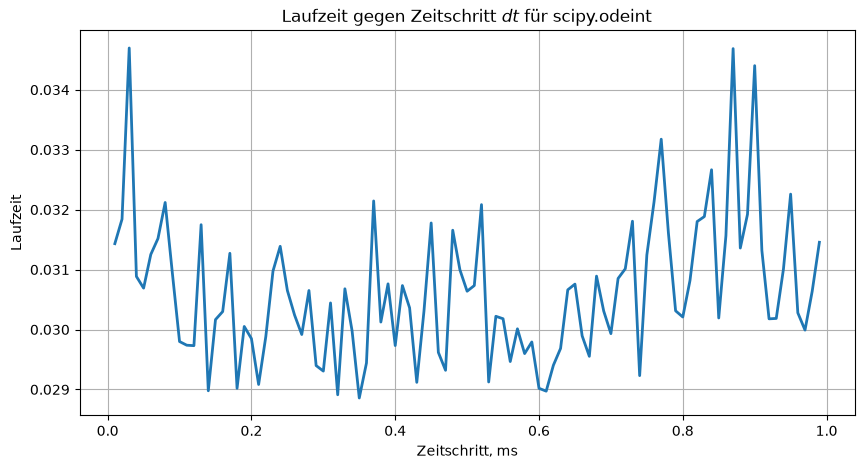

In [7]:
from aufgabe2 import visualizer

time_steps = np.arange(0.01, 1, 0.01)

odeint_array = visualizer.visualize_odeint_performance(x_0, t_a, t_b, time_steps, I_0)

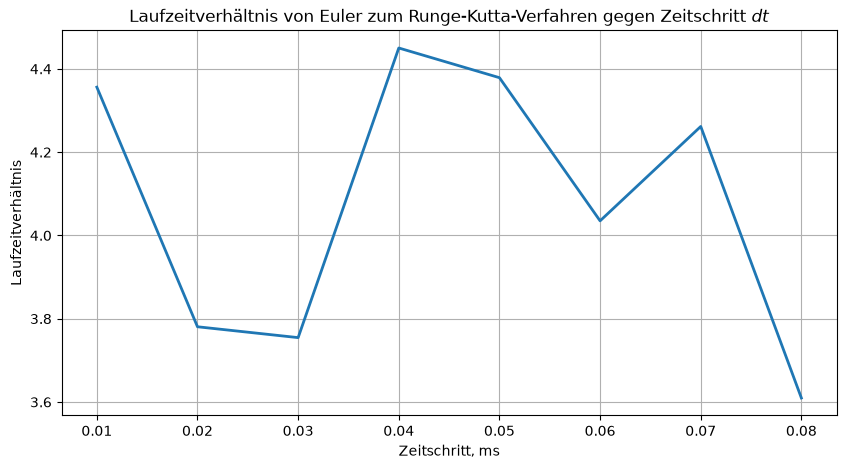

In [6]:
from aufgabe2 import visualizer

time_steps = np.arange(0.01, 1, 0.01)

visualizer.visualize_comparison(euler_array, runge_kutta_array, time_steps)

**Aufgabe 2.c**

Wir rechnen den Verlauf der Spannung für Stromwerte von -5 bis zu 15 nA. Es fällt uns auf, dass in ersten ca.3 mS alle Stromstärken Spannungsausschlag verursachen, bleibt das Neuron danach im Ruhezustand nur für Strom $I \in [-5,5]$. Weiterhin steigt die Frequenz der Spannung mit Strom.

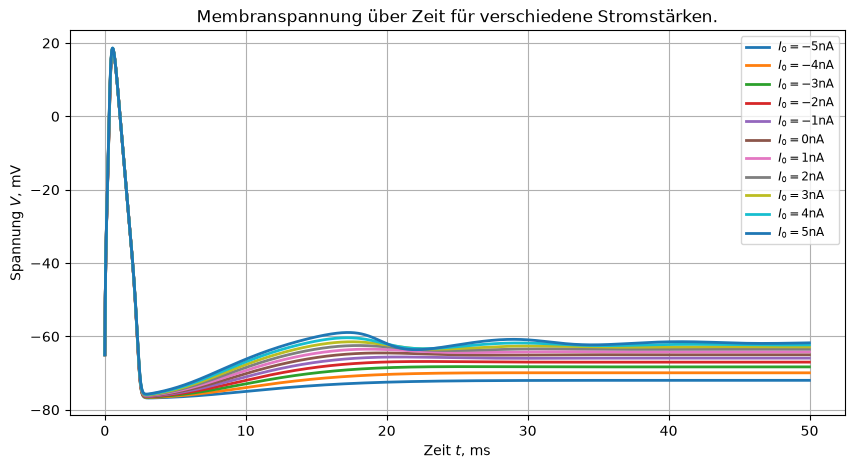

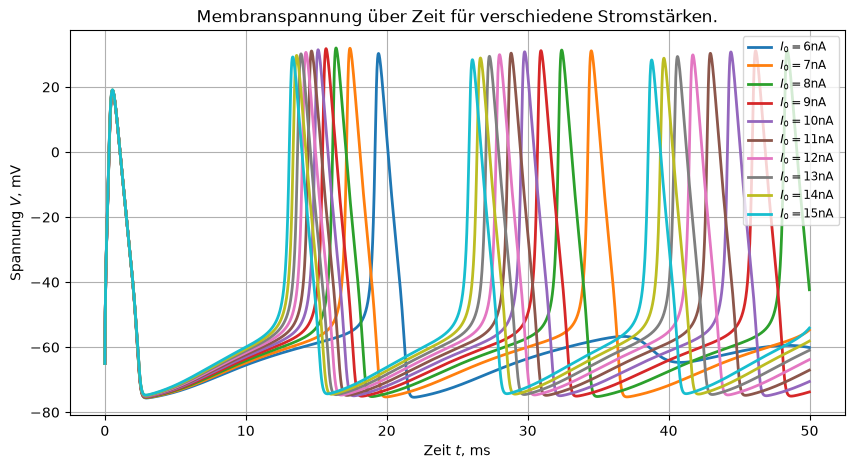

In [8]:
from aufgabe2 import visualizer
visualizer.visualize_c(x_0,t_a, t_b, dt)


**Aufgabe 2.d**

In der unteren Zeile befinden sich die graphische Darstellungen von $U, I, n, m, h$ im Zeitraum von 50 ms. Der Stromimpuls ist gegen durch:
$$
I = \begin{cases}
      50 \text{ nA} &, \ t \in [10,11] \\
      4 \text{ nA} &, \ \text{sonst} \\
   \end{cases}
$$
Dieser Impuls verursacht rasche Steigung der Spannung $V$ und der Gating-Variablen$n, m, h$. Nach dem Impuls erreicht das System wieder den Ruhezustand. Die Gating-Variablen erreichen ihren terminalen Zustand, wie es in der Aufgabe 1.a vorhergesagt wurde. Aus dem Diagram für die Gating-Variable $h$ entnehmen wir, dass der Zweck von $h$ das Neuron zu beruhigen ist, da es umgekehrt proportional zu der Spannung wächst.

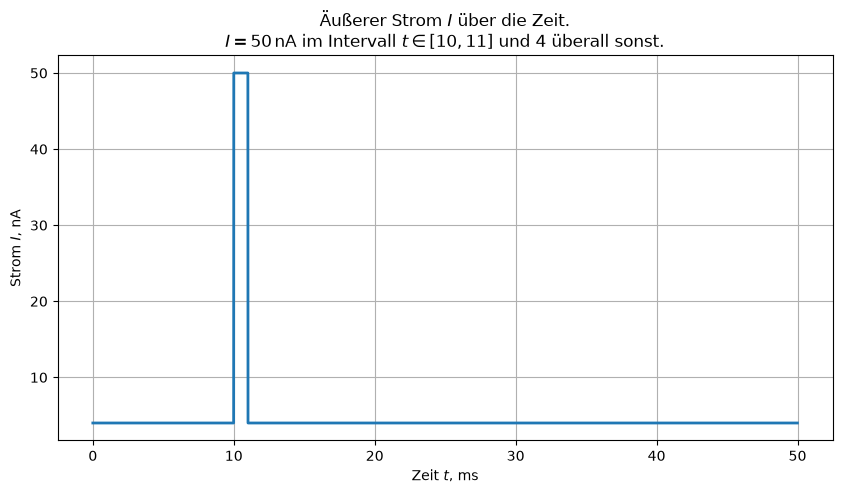

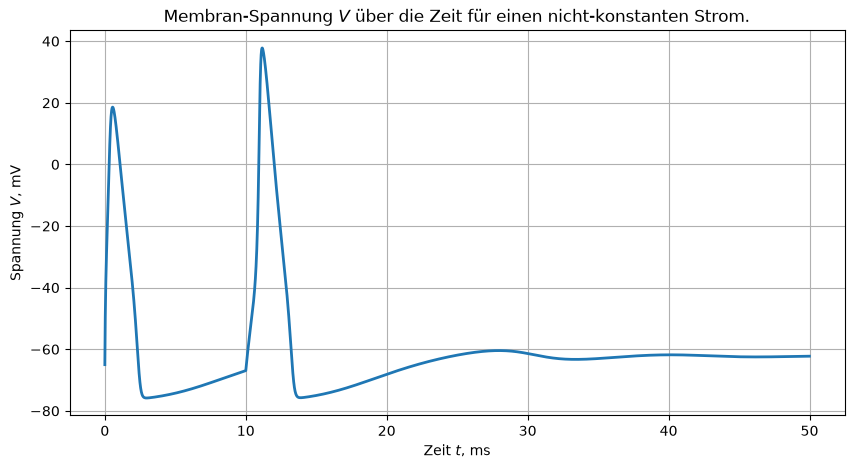

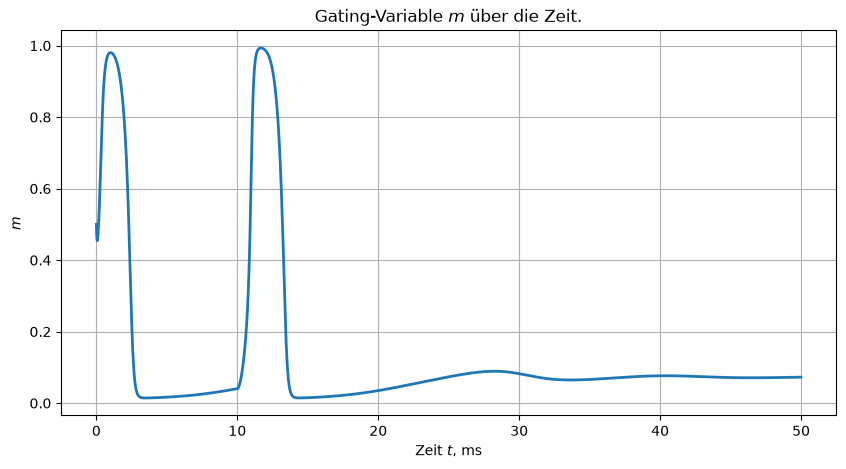

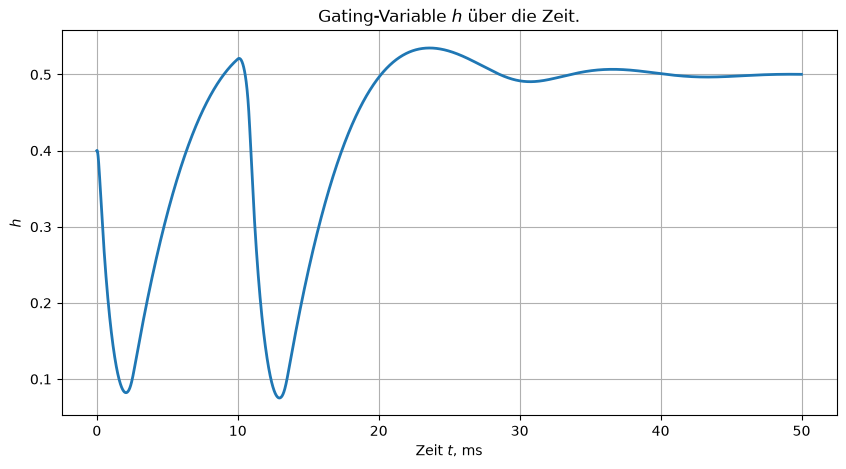

In [9]:
from aufgabe2 import visualizer
visualizer.visualize_d(x_0, t_a, t_b, dt)
